# Quick Boys Stadium Expansion

This notebook investigades a Multi-Objective Design Optimisation (MODO) model for an expansion of the quick boys stadium in Katwijk. The following information can be found:

- Define design variables and bounds
- Specify multiple constraints and objective functions
- Run a Algorithm to calculate optimization
- Visualize preference functions and optimization results





In [16]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import pchip_interpolate
from scipy.optimize import minimize, differential_evolution, NonlinearConstraint

## Variables and Bounds


| Variable | Description | Unit | Type |
|----------|-------------|------|------|
| `x1` | Number of seats | - | Discrete |
| `x2` | Number of parking places | - | Discrete |
| `x3` | Width of tribune | m | Discrete |
| `x4` | Length of tribune | m | Discrete | 
| `x5` | Number of rows | - | Discrete | 

The investment is no longer a design variable: it follows from the design (`cost(x1, x2, x3, x4)`) and is limited by a budget constraint (see below).

In [17]:
# set bounds for all variables
b1 = [350, 900]      # x1
b2 = [250, 600]      # x2
b3 = [10, 25]        # x3
b4 = [45, 90]        # x4
b5 = [5, 20]         # x5
bounds = [b1, b2, b3, b4, b5]

## Constraints

**Budget:** the total cost of the rebuilding may not exceed the available budget:

$$\text{cost}(x_1, x_2, x_3, x_4) \le \text{BUDGET}$$

Change `BUDGET` below to the real budget of the club.

In [18]:
# Constraint functions
BUDGET = 1_500_000   # Available budget in euros (adjust to the real budget)

# cost() is defined in the objectives section below; it is only looked up when the constraint is evaluated
budget_constraint = NonlinearConstraint(lambda x: cost(*x[:4]), -np.inf, BUDGET)

## Objectives

| Stakeholder | Objective | Unit |
|-------------|-----------|------|
| Residents | Noise | dB |
| Environment | Environmental impact | CO2 |
| Quick Boys | Rendement on Investment | €/year |
| Fans | Comfort | - (1 = comfortable) |
| Players | Player Facilities | m<sup>2</sup> |
| Authorities | Fire/Emergency Access | s|

In [19]:
"""
x1: Number of seats
x2: Number of parking spaces
x3: Width tribune [m]
x4: Length tribune [m]
x5: Number of rows
"""

def structure_factor(x1):
    """
    This function defines the structure factor, because the higher the supporters per area, the higher the quality of bearing structure.
    Output: factor
    """
    str_factor = 0.5     # This makes sense
    return 1 + (str_factor*(x1-350)) / 900

def cost(x1, x2, x3, x4):
    """
    This function defines the cost of the rebuilding of the stadium.
    Output: Cost in euros
    """
    cost_seat = 500       # Cost per seat
    cost_parking = 1000   # Cost per parking space
    cost_tribune = 500    # Cost per m^2 of the tribune
    return cost_seat*x1 + cost_parking*x2 + cost_tribune*x3*x4*structure_factor(x1)

def obj_func_1(x1, x2, x3, x4, x5):
    """ 
    This objective function defines the noise output from the stadium.
    Output: Noise in dB arriving at the residents.

    This function is currently outputting an index
    """
    basic_seat = 65     # Sound of 1 supporter
    basic_car = 60      # Sound of 1 car

    noise_seat = basic_seat + 10*np.log10(x1)    # Noise per seat
    noise_parking = basic_car + 10*np.log10(x2)  # Noise per parking place
    return 10*np.log10(10**(noise_seat/10) + 10**(noise_parking/10))

def obj_func_2(x1, x2, x3, x4, x5):
    """ 
    This objective function defines the environmental impact in CO2.
    Output: kg CO2
    """
    co2_parking = 250   # kg CO2 per parking space
    co2_tribune = 500   # kg CO2 per m^2 of the tribune
    return  co2_parking*x2 + co2_tribune*x3*x4*structure_factor(x1)

def obj_func_3(x1, x2, x3, x4, x5):
    """ 
    This objective function defines the return on investment.
    Output: €
    """
    rev_ticket = 10     # Ticket price
    rev_sponsor = 2     # Sponsoring
    rev_bar = 10        # Consumptions
    occupancy = 0.75    # Attendance of supporters
    games = 17          # Number of games per year
    annual_cost = 0.1 * cost(x1, x2, x3, x4)   # Annual cost of maintenance
    revenue = (rev_ticket+rev_sponsor+rev_bar)*occupancy*games*x1
    return 100*(revenue - annual_cost) / cost(x1, x2, x3, x4)

def obj_func_4(x1, x2, x3, x4, x5):
    """ 
    This objective function defines the comfort of fans.
    The tribune (width x3, length x4) holds x5 rows with x1 seats in total, so per fan:
        row depth  = x3 / x5           [m]  (legroom, space to walk past)
        seat width = x4 * x5 / x1      [m]  (elbow room along the row)
    Both are compared to a comfortable reference value, and the worst of the two decides
    (a fan is only comfortable if neither legroom nor seat width is lacking).
    Output: comfort index [-]; 1.0 = reference comfort, <1 cramped, >1 spacious.
    """
    depth_ref = 0.85    # Comfortable row depth [m]
    width_ref = 0.55    # Comfortable seat width [m]

    row_depth = x3 / x5
    seat_width = x4 * x5 / x1
    return np.minimum(row_depth / depth_ref, seat_width / width_ref)

def obj_func_5(x1, x2, x3, x4, x5):
    """ 
    This objective function defines the player facilities.
    Output: m^2 total
    """
    A_player = 0.1      # Area of the tribune that is dedicated to players
    return A_player*x3*x4

def obj_func_6(x1, x2, x3, x4, x5):
    """ 
    This objective function defines m^2 per spectator for emergency access.
    Output: m^2 / supporter
    """
    A_seat = 0.5        # Area of a seat
    return (x3*x4 - A_seat*x1) / x1

In [20]:
objectives = [
    (obj_func_1, "Noise",                   "dB",               "Residents"),
    (obj_func_2, "Environmental impact",    "CO2",              "Environment"),
    (obj_func_3, "Rendement on Investment", "% / investment",   "Quick Boys"),
    (obj_func_4, "Comfort",                 "-",                "Fans"),
    (obj_func_5, "Player Facilities",       "m^2",              "Players"),
    (obj_func_6, "Fire/Emergency Access",   "s",              "Authorities")
]

Evaluate min and max points per function

In [21]:
# Finding min and max for each objective over the design bounds.
# differential_evolution is used because the comfort index (a min of two ratios) has a kink,
# which a local method such as L-BFGS-B can get stuck on.
objective_minmax = {} # Dictionary to store the min and max values for each objective

for i, (obj_func, name, unit, stakeholder) in enumerate(objectives):
    f = lambda x, sign=1: sign * obj_func(*x)

    min_val =  differential_evolution(f, bounds, seed=1, tol=1e-8).fun
    max_val = -differential_evolution(lambda x: f(x, sign=-1), bounds, seed=1, tol=1e-8).fun

    objective_minmax[name] = min_val, max_val
    print(f"  Objective {name:<25}  :    min = {min_val:>15,.2f}  {unit:<15}    max = {max_val:>15,.2f}  {unit}")

  Objective Noise                      :    min =           91.33  dB                 max =           95.37  dB
  Objective Environmental impact       :    min =      287,500.00  CO2                max =    1,618,749.99  CO2
  Objective Rendement on Investment    :    min =           -4.83  % / investment     max =           15.40  % / investment
  Objective Comfort                    :    min =            0.45  -                  max =            3.71  -
  Objective Player Facilities          :    min =           45.00  m^2                max =          225.00  m^2
  Objective Fire/Emergency Access      :    min =            0.00  s                  max =            5.93  s


In [22]:
weights =    [2/14, 3/14, 3/14, 2/14, 1/14, 3/14]
assert np.isclose(sum(weights), 1.0), f"Weights must sum to 1, got {sum(weights)}"

[[90, 96], [100, 0]]
[[300000, 1500000], [100, 0]]
[[5, 50], [0, 100]]
[[0.6, 1.0, 1.5], [0, 70, 100]]
[[90, 200], [0, 100]]
[[0, 5], [100, 0]]


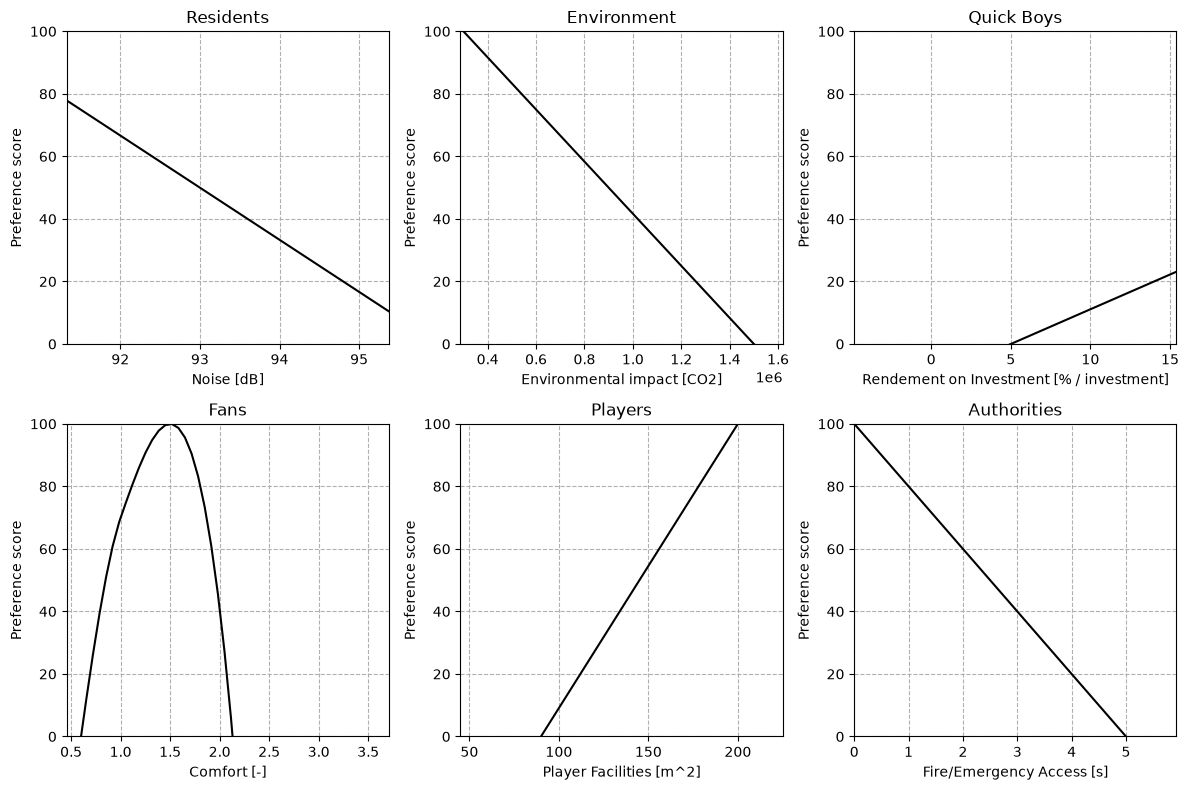

In [23]:
# Define preferences
prefs =        [[[90, 96],                      [100, 0]],          # preference noise
                [[300000, 1500000],             [100, 0]],          # preference m^3 co2
                [[5, 50],                       [0, 100]],          # preference ROI
                [[0.6, 1.0, 1.5],               [0, 70, 100]],      # preference comfort index (1 = reference comfort)
                [[90, 200],                     [0, 100]],          # preference index
                [[0, 5],                        [100, 0]]]          # preference fire emergency time


# Preference curve values for plotting
# Generate objective value ranges 
obj_vals_list = []
for _, name, _, _ in objectives:
    obj_vals = np.linspace(*objective_minmax[name])
    obj_vals_list.append(obj_vals)

# Generate preference values using interpolation
pref_vals_list = []
for pref, obj_vals in zip(prefs, obj_vals_list):
    print(pref)
    pref_vals = pchip_interpolate(pref[0], pref[1], obj_vals)
    pref_vals_list.append(pref_vals)

# Plotting the preference curves 
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, (obj_vals, p_vals), (_, name, unit, stakeholder) in zip(axes.flat, zip(obj_vals_list, pref_vals_list), objectives): # Loop to plot each preference curve in its own subplot
    ax.plot(obj_vals, p_vals, color='black')
    ax.set_xlim(min(obj_vals), max(obj_vals))
    ax.set_ylim(0, 100)
    ax.set_title(stakeholder)
    ax.set_xlabel(f'{name} [{unit}]')
    ax.set_ylabel('Preference score')
    ax.grid(linestyle='--')

#axes.flat[-1].set_visible(False)  # hide empty 6th subplot
fig.tight_layout()
# plt.savefig('preference_curves.png')  # Uncomment this line to save the figure as a PNG file
plt.show()


# Defines preference functions that convert raw objective values to 0-100 preference scores
# (clipped, because pchip extrapolates outside the curve range)
def pref_func_1(x1, x2, x3, x4, x5):
    noise = obj_func_1(x1, x2, x3, x4, x5)
    return np.clip(pchip_interpolate(prefs[0][0], prefs[0][1], noise), 0, 100)

def pref_func_2(x1, x2, x3, x4, x5):
    environment = obj_func_2(x1, x2, x3, x4, x5)
    return np.clip(pchip_interpolate(prefs[1][0], prefs[1][1], environment), 0, 100)

def pref_func_3(x1, x2, x3, x4, x5):
    rend = obj_func_3(x1, x2, x3, x4, x5)
    return np.clip(pchip_interpolate(prefs[2][0], prefs[2][1], rend), 0, 100)

def pref_func_4(x1, x2, x3, x4, x5):
    comfort = obj_func_4(x1, x2, x3, x4, x5)
    return np.clip(pchip_interpolate(prefs[3][0], prefs[3][1], comfort), 0, 100)

def pref_func_5(x1, x2, x3, x4, x5):
    facilities = obj_func_5(x1, x2, x3, x4, x5)
    return np.clip(pchip_interpolate(prefs[4][0], prefs[4][1], facilities), 0, 100)

def pref_func_6(x1, x2, x3, x4, x5):
    access = obj_func_6(x1, x2, x3, x4, x5)
    return np.clip(pchip_interpolate(prefs[5][0], prefs[5][1], access), 0, 100)

pref_funcs = [pref_func_1, pref_func_2, pref_func_3, pref_func_4, pref_func_5, pref_func_6]  # list of preference functions for easier handling

In [ ]:
weights_arr = np.array(weights)

def total_preference(x):
    """Weighted aggregate preference (0-100) for one design vector x = [x1..x5]."""
    scores = np.array([f(*x) for f in pref_funcs], dtype=float).ravel()
    return float(weights_arr @ scores)

def neg_total_preference(x):
    return -total_preference(x)               # optimisers minimise, so flip the sign

def objective(variables):
    """Aggregated preference for a population (rows = designs). Maximise this."""
    variables = np.atleast_2d(variables)
    return np.array([total_preference(v) for v in variables])

# Global optimisation, subject to the budget constraint
result = differential_evolution(
    neg_total_preference,
    bounds=bounds,
    constraints=budget_constraint,
    seed=1,
    popsize=30,
    maxiter=500,
    tol=1e-8,
    polish=True,          # local refinement at the end
)

x_opt = result.x
print(f"Converged: {result.success}")
print(f"Best aggregated preference: {-result.fun:.2f} / 100")
names = ["Seats", "Parking spaces", "Tribune width [m]", "Tribune length [m]", "Rows"]
for n, v in zip(names, x_opt):
    print(f"  {n:<20} = {v:,.2f}")

# Per-objective breakdown
print("\nObjective breakdown:")
for (f_obj, name, unit, stakeholder), f_pref, w in zip(objectives, pref_funcs, weights):
    raw = f_obj(*x_opt)
    p = float(f_pref(*x_opt))
    print(f"  {stakeholder:<12} {name:<25} raw = {raw:>12,.2f} {unit:<15} pref = {p:6.1f}  (w = {w:.2f})")

print(f"\nCost of design: €{cost(*x_opt[:4]):,.0f}  (budget: €{BUDGET:,.0f})")

Converged: True
Best aggregated preference: 65.23 / 100
  Seats                = 438.95
  Parking spaces       = 250.00
  Tribune width [m]    = 10.00
  Tribune length [m]   = 45.00
  Rows                 = 7.94

Objective breakdown:
  Residents    Noise                     raw =        92.14 dB              pref =   64.3  (w = 0.14285714285714285)
  Environment  Environmental impact      raw =   298,618.95 CO2             pref =  100.0  (w = 0.21428571428571427)
  Quick Boys   Rendement on Investment   raw =         7.45 % / investment  pref =    5.4  (w = 0.21428571428571427)
  Fans         Comfort                   raw =         1.48 -               pref =   99.9  (w = 0.14285714285714285)
  Players      Player Facilities         raw =        45.00 m^2             pref =    0.0  (w = 0.07142857142857142)
  Authorities  Fire/Emergency Access     raw =         0.53 s               pref =   89.5  (w = 0.21428571428571427)

Cost of design: €705,595  (budget: €1,500,000)


In [25]:
# Robustness check: repeat the global optimisation with different random seeds and keep the best design
best_result = None

for seed in range(1, 4):
    res = differential_evolution(
        neg_total_preference,
        bounds=bounds,
        constraints=budget_constraint,
        seed=seed,
        popsize=20,
        maxiter=300,
        tol=1e-6,
    )
    print(f"seed {seed}: satisfaction = {-res.fun:6.2f}, cost = €{cost(*res.x[:4]):,.0f}")
    if best_result is None or res.fun < best_result.fun:
        best_result = res

x_opt = best_result.x
max_satisfaction = -best_result.fun

print("\nOptimal variables:")
for i, value in enumerate(x_opt, start=1):
    print(f"x{i} = {value:.2f}")

print(f"\nMaximum satisfaction = {max_satisfaction:.2f}")
print(f"The investment is: €{cost(*x_opt[:4]):,.0f} (budget: €{BUDGET:,.0f})")

seed 1: satisfaction =  65.23, cost = €705,677
seed 2: satisfaction =  65.23, cost = €705,605
seed 3: satisfaction =  65.23, cost = €705,782

Optimal variables:
x1 = 438.97
x2 = 250.00
x3 = 10.00
x4 = 45.00
x5 = 7.94

Maximum satisfaction = 65.23
The investment is: €705,605 (budget: €1,500,000)
